In [1]:
import numpy as np
import matplotlib.pyplot as plt
from chempiler import ChempilerTrajectory
from chempiler.segmentation import segment_by_molecule_count
from chempiler.core.statistics import block_average

## Load

In [2]:
traj = ChempilerTrajectory("tests/39_water_OH.traj")
traj.build(cache_file="tests/cache_file.h5")

[Chempiler] loaded cache → tests/cache_file.h5


## Composition

In [3]:
traj.summary()

{'H6O3': 28,
 'H2O': 149623,
 'H3O2': 1851,
 'HO': 1507,
 'H4O2': 1542,
 'H5O3': 580,
 'H7O4': 59,
 'H8O4': 2,
 'H9O5': 2,
 'H11O6': 1}

Text(0, 0.5, 'Molecules')

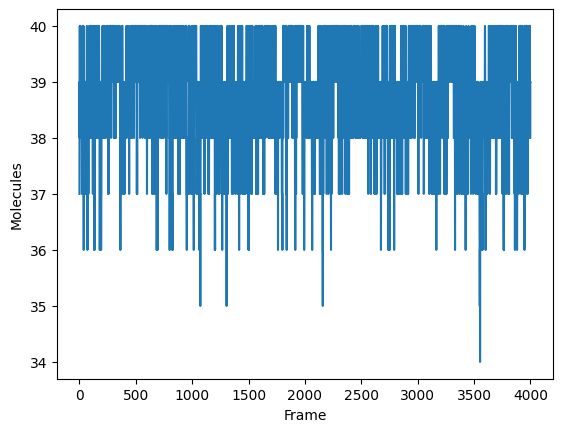

In [4]:
mol_counts = [len(f.molecules) for f in traj.frames]
plt.plot(mol_counts)
plt.xlabel("Frame"); plt.ylabel("Molecules")

In [20]:
# Contiguous intervals where HO is present
lt_segs = traj.lifetime_segments("HO")
for i, seg in enumerate(lt_segs[:5]):
    print(f"Segment {i}: frames {seg[0]} to {seg[1]} (length {seg[1]-seg[0]+1})")

Segment 0: frames 1 to 2 (length 2)
Segment 1: frames 3 to 4 (length 2)
Segment 2: frames 6 to 7 (length 2)
Segment 3: frames 11 to 12 (length 2)
Segment 4: frames 27 to 28 (length 2)


## RDF

[RDF] rmax = 5.186 Å (auto)


[Text(0.5, 0, 'r (Å)'),
 Text(0, 0.5, 'n(r)'),
 Text(0.5, 1.0, 'O–H coordination number')]

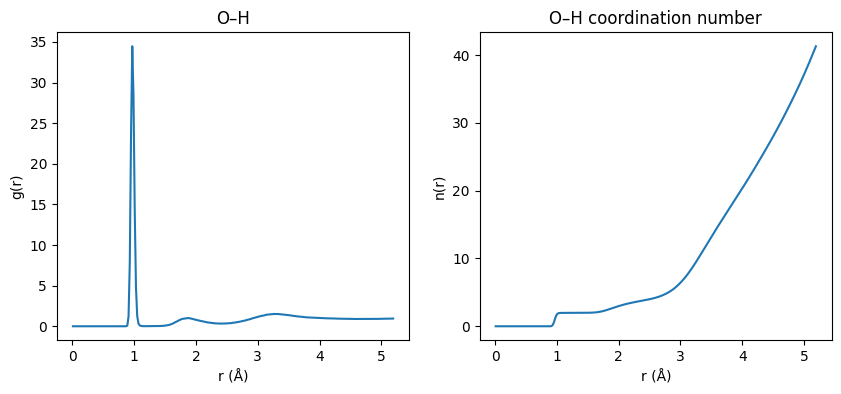

In [6]:
r, g, n = traj.rdf(center="O", target="H", dr=0.02, integrate=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(r, g); ax1.set(xlabel="r (Å)", ylabel="g(r)", title="O–H")
ax2.plot(r, n); ax2.set(xlabel="r (Å)", ylabel="n(r)", title="O–H coordination number")

[RDF] rmax = 5.186 Å (auto)


Text(0.5, 1.0, 'O–O')

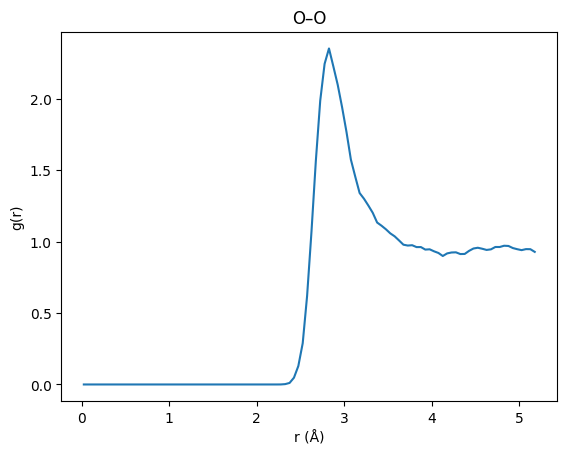

In [7]:
r, g, _ = traj.rdf(center="O", target="O", dr=0.05, integrate=True)
plt.plot(r, g); plt.xlabel("r (Å)"); plt.ylabel("g(r)"); plt.title("O–O")

### Selectors
Restrict centers or targets to atoms inside specific molecules.

[RDF] rmax = 5.186 Å (auto)
[RDF] rmax = 5.186 Å (auto)
CN H₂O (r < 1.4 Å): 2.00
CN HO  (r < 1.4 Å): 1.00


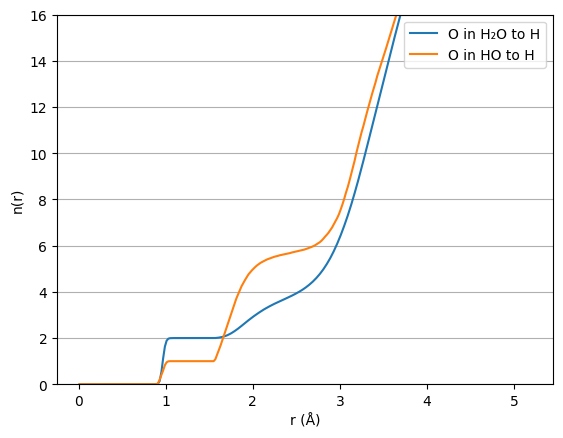

In [8]:
r_w, _, n_w = traj.rdf(center={"H2O": "O"}, target="H", dr=0.02, integrate=True)
r_h, _, n_h = traj.rdf(center={"HO":  "O"}, target="H", dr=0.02, integrate=True)

plt.plot(r_w, n_w, label="O in H₂O to H")
plt.plot(r_h, n_h, label="O in HO to H")
plt.xlabel("r (Å)"); plt.ylabel("n(r)")
plt.ylim(0, 16)
plt.grid(axis="y")
plt.legend()

print(f"CN H₂O (r < 1.4 Å): {n_w[r_w < 1.4][-1]:.2f}")   # expect 2
print(f"CN HO  (r < 1.4 Å): {n_h[r_h < 1.4][-1]:.2f}")   # expect 1

## MSD

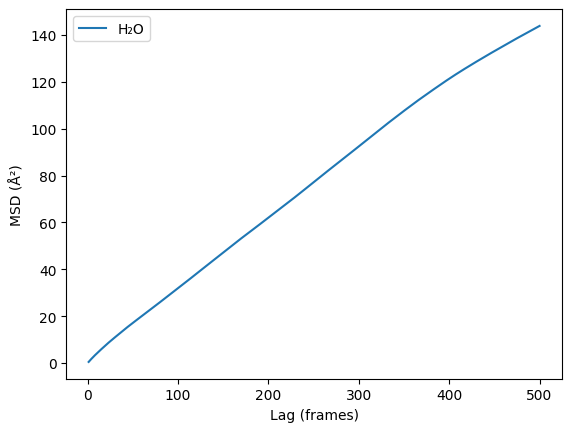

In [9]:
lags, msd, n_samples = traj.msd("H2O", max_lag=500)
plt.plot(lags, msd, label="H₂O")
plt.xlabel("Lag (frames)")
plt.ylabel("MSD (Å²)")
plt.legend()

In [10]:
# Diffusion coefficient from linear region
dt = 5e-15   # s per frame (0.5 fs timestep × 10 steps between frames)
mask = (lags >= 50) & (lags <= 300)
slope = np.polyfit(lags[mask] * dt, msd[mask] * 1e-20, 1)[0]
D = slope / 6
print(f"D(H₂O) = {D:.3e} m²/s")

D(H₂O) = 1.004e-07 m²/s


## Segmentation

In [11]:
segs = segment_by_molecule_count(traj.frames, block=100, threshold=0.5)
segs

[(0, 600),
 (600, 800),
 (800, 1200),
 (1200, 2000),
 (2000, 2300),
 (2300, 2900),
 (2900, 3100),
 (3100, 3200),
 (3200, 3500),
 (3500, 3600),
 (3600, 4000)]

[RDF] rmax = 5.233 Å (auto)
[RDF] rmax = 5.150 Å (auto)
[RDF] rmax = 5.205 Å (auto)
[RDF] rmax = 5.151 Å (auto)
[RDF] rmax = 5.205 Å (auto)
[RDF] rmax = 5.206 Å (auto)
[RDF] rmax = 5.129 Å (auto)
[RDF] rmax = 5.186 Å (auto)
[RDF] rmax = 5.185 Å (auto)


Text(0.5, 1.0, 'O–O per segment')

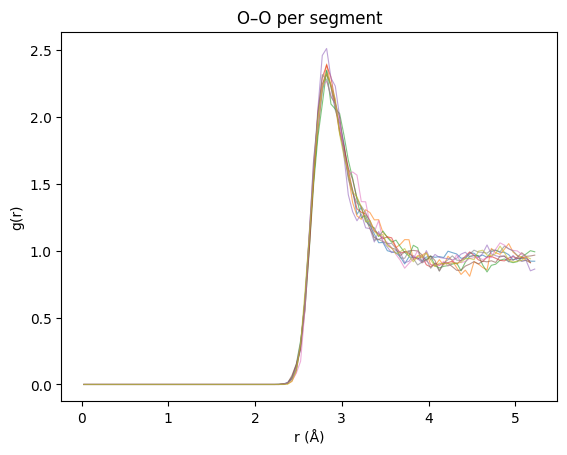

In [12]:
# Per-segment RDF to check stability
from chempiler.rdf import rdf as rdf_fn

for start, end in segs:
    if end - start < 200:
        continue
    r, g = rdf_fn(traj.frames[start:end], center="O", target="O", dr=0.05)
    plt.plot(r, g, alpha=0.6, lw=0.8)

plt.xlabel("r (Å)"); plt.ylabel("g(r)"); plt.title("O–O per segment")

## Block averaging

In [13]:
stats = block_average(np.array(mol_counts, dtype=float), tau_corr=50)
print(f"mean = {stats['mean']:.3f} ± {stats['stderr']:.3f}  ({stats['n_blocks']} blocks)")

mean = 38.799 ± 0.040  (80 blocks)


---
## Reaction kinetics

How often does HO appear, and how long does it typically survive? Most events are sub-picosecond recrossings; the tail shows the rare events that persist for tens of frames.

Events:          386
Mean lifetime:   19.5 fs
Median lifetime: 5.0 fs
Event rate:      1.930e+13 s⁻¹


Text(0, 0.5, 'Count')

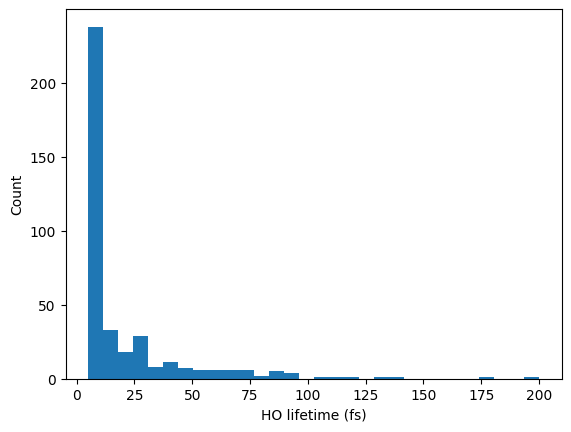

In [14]:
from chempiler.kinetics import reaction_kinetics

dt = 5e-15  # s per frame
k = reaction_kinetics(traj.frames, "HO", dt=dt)

print(f"Events:          {k['n_events']}")
print(f"Mean lifetime:   {k['mean_lifetime']*1e15:.1f} fs")
print(f"Median lifetime: {k['median_lifetime']*1e15:.1f} fs")
print(f"Event rate:      {k['rate']:.3e} s⁻¹")

plt.hist(k['lifetimes'] * 1e15, bins=30)
plt.xlabel("HO lifetime (fs)"); plt.ylabel("Count")

## H-bond dynamics

The intermittent H-bond ACF C(τ) is the probability that a bond present at t=0 is also present at t=τ, regardless of what happened in between. The decay timescale is the structural relaxation time of the H-bond network.

Mean H-bonds per frame: 73.9 ± 4.1


Text(0.5, 1.0, 'H-bond ACF')

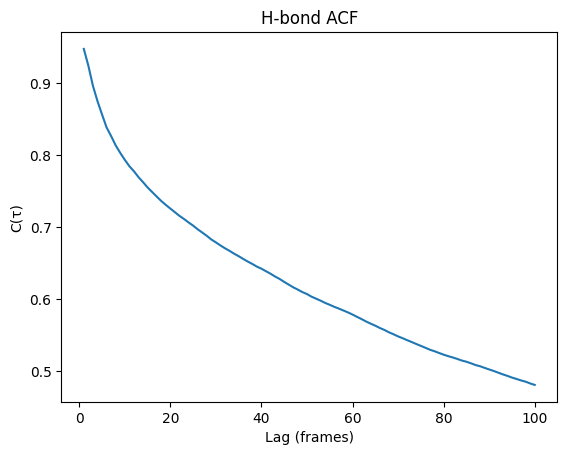

In [15]:
from chempiler.hbond import hbond_acf, hbond_count

n_hb = hbond_count(traj.frames)
print(f"Mean H-bonds per frame: {n_hb.mean():.1f} ± {n_hb.std():.1f}")

lags_hb, C = hbond_acf(traj.frames[:1000], max_lag=100)
plt.plot(lags_hb, C)
plt.xlabel("Lag (frames)"); plt.ylabel("C(τ)"); plt.title("H-bond ACF")

## Angular distribution

Distribution of H-O-H bond angles within H₂O molecules. The peak reflects the instantaneous intramolecular geometry. The gas-phase value is 104.5°; liquid-phase broadening and shift are due to H-bonding.

Peak H-O-H angle: 104.3°


Text(0, 0.5, 'P(θ)')

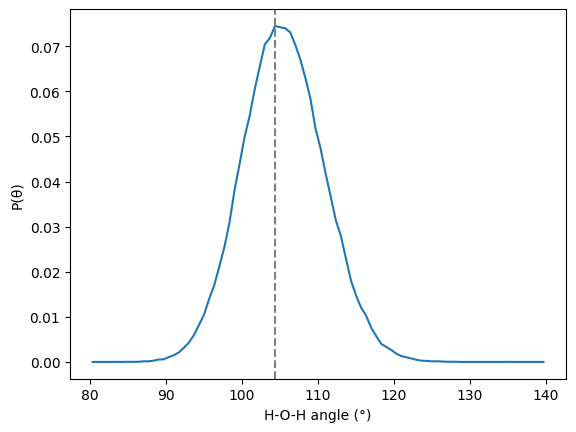

In [16]:
from chempiler.adf import adf

angles, density = adf(traj.frames, center="O", neighbors="H", formula="H2O")
peak = angles[np.argmax(density)]
print(f"Peak H-O-H angle: {peak:.1f}°")

plt.plot(angles, density)
plt.axvline(peak, ls="--", color="0.5")
plt.xlabel("H-O-H angle (°)"); plt.ylabel("P(θ)")

## Tetrahedral order

q = 1 − (3/8) Σ_{j<k} (cos θ_jik + 1/3)² over the four nearest O neighbours of each O. q = 1 for ice, q ≈ 0.6 for ambient liquid water, q ≈ 0 for a random arrangement. Values here reflect the elevated-temperature/pressure reactive simulation conditions.

Mean q = 0.560 ± 0.041


Text(0, 0.5, 'q')

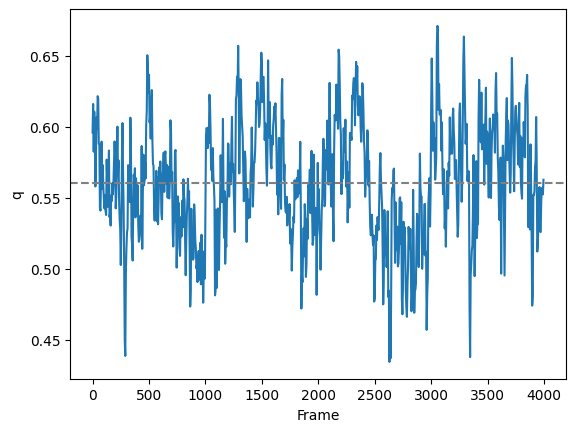

In [17]:
from chempiler.tetrahedral import tetrahedral_order

q = tetrahedral_order(traj.frames[::5])   # subsample — ~800 frames
print(f"Mean q = {np.nanmean(q):.3f} ± {np.nanstd(q):.3f}")

plt.plot(np.arange(len(q)) * 5, q)
plt.axhline(np.nanmean(q), ls="--", color="0.5")
plt.xlabel("Frame"); plt.ylabel("q")

## Van Hove self-correlation

G_s(r, τ) is the distribution of molecular displacements at lag τ. At short lags it is a narrow peak near r = 0. At long lags it broadens and shifts outward as molecules diffuse. A Gaussian shape at long lags confirms normal (Fickian) diffusion.

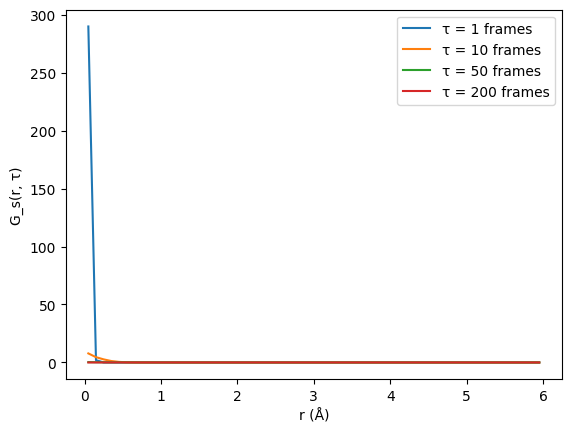

In [18]:
from chempiler.vanhove import van_hove

lag_vals = [1, 10, 50, 200]
r_vh, G = van_hove(traj.frames, "H2O", lags=lag_vals)

for i, lag in enumerate(lag_vals):
    plt.plot(r_vh, G[i], label=f"τ = {lag} frames")

plt.xlabel("r (Å)"); plt.ylabel("G_s(r, τ)")
plt.legend()

## Proton hop network

Track which hydrogen atoms transfer between oxygen hosts, and how many times each oxygen acts as donor or acceptor. Oxygens with high counts are the most reactive sites.

Total proton transfer events: 26


Text(0, 0.5, 'Hop events')

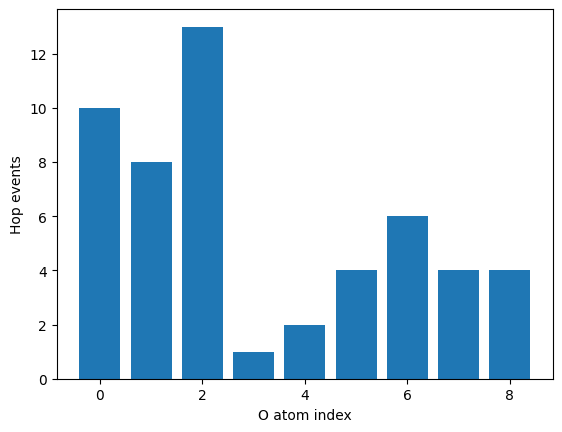

In [19]:
from chempiler.state_engine import atom_hop
from collections import Counter

hops = atom_hop(traj.frames, tracked="H", host="O", cutoff=1.25, persistence=2)
print(f"Total proton transfer events: {hops['n_transitions']}")

involvement = Counter()
for _, _, from_o, to_o in hops["transitions"]:
    if from_o is not None: involvement[from_o] += 1
    if to_o   is not None: involvement[to_o]   += 1

o_ids, counts = zip(*sorted(involvement.items())) if involvement else ([], [])
plt.bar(range(len(o_ids)), counts)
plt.xlabel("O atom index"); plt.ylabel("Hop events")